#  Student Performance Analysis & GPA Prediction  
### Detailed Exploratory Data Analysis (EDA)  
Dataset: Kaggle — Students Performance Dataset

This notebook performs a complete data exploration and prepares the dataset for machine learning.  
We analyze academic, behavioral, and demographic factors that influence **student GPA**.


In [83]:
import os
import kagglehub
import pandas as pd
import glob
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style="whitegrid")

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


In [ ]:

custom_path = "C:\DATA SCIENCE\projects_\student_performance_analysis"
os.environ["KAGGLEHUB_CACHE"] = custom_path
path = kagglehub.dataset_download("rabieelkharoua/students-performance-dataset")
print("Dataset downloaded to:", path)
csv_files = glob.glob(path + "/*.csv")
df = pd.read_csv(csv_files[0])

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\abhay\AppData\Local\Temp\ipykernel_6652\3877105510.py:1: SyntaxWarning: invalid escape sequence '\D'
  custom_path = "C:\DATA SCIENCE\projects_\student performance analysis"


Dataset downloaded to: C:\DATA SCIENCE\projects_\student performance analysis\datasets\rabieelkharoua\students-performance-dataset\versions\2


##  Introduction

Student performance is shaped by many factors including study habits, attendance, family background, and participation in extracurricular activities.

This dataset contains key features such as:

- Age  
- Gender  
- Ethnicity  
- Parental education  
- Weekly study time  
- Absences  
- Tutoring  
- Parental support  
- Extracurriculars  
- Sports / Music / Volunteering  
- GPA  
- Grade Class

The goal is to:

1. Understand relationships between behavioral & academic features  
2. Identify patterns affecting performance  
3. Prepare data for predictive modeling  


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB


In [48]:
df.isnull().sum()

StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64

In [59]:
df.describe(include='all')


,studentid,age,gender,ethnicity,parentaleducation,studytimeweekly,absences,tutoring,parentalsupport,extracurricular,sports,music,volunteering,gpa,gradeclass
count,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000
mean,2196.500000,16.468645,0.510870,0.877508,1.746237,9.771992,14.541388,0.301421,2.122074,0.383361,0.303512,0.196906,0.157191,1.906186,2.983696
std,690.655244,1.123798,0.499986,1.028476,1.000411,5.652774,8.467417,0.458971,1.122813,0.486307,0.459870,0.397744,0.364057,0.915156,1.233908
min,1001.000000,15.000000,0.000000,0.000000,0.000000,0.001057,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1598.750000,15.000000,0.000000,0.000000,1.000000,5.043079,7.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.174803,2.000000
50%,2196.500000,16.000000,1.000000,0.000000,2.000000,9.705363,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.893393,4.000000
75%,2794.250000,17.000000,1.000000,2.000000,2.000000,14.408410,22.000000,1.000000,3.000000,1.000000,1.000000,0.000000,0.000000,2.622216,4.000000
max,3392.000000,18.000000,1.000000,3.000000,4.000000,19.978094,29.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,4.000000,4.000000


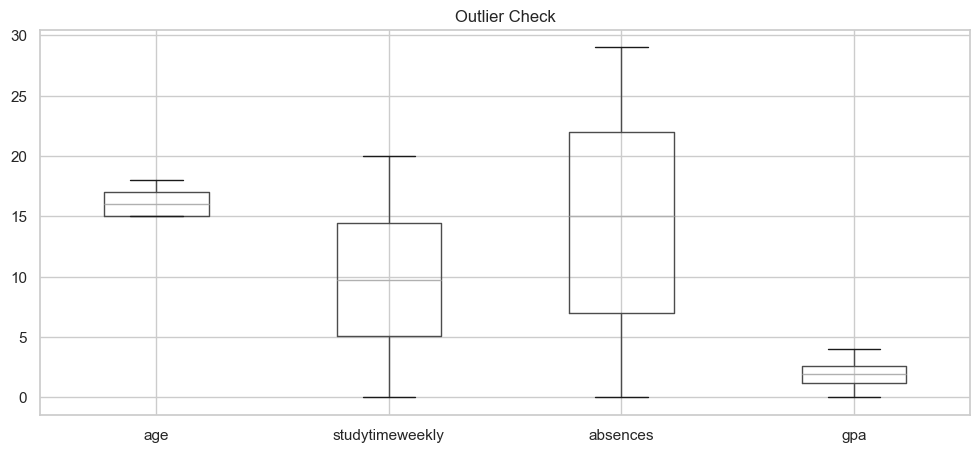

In [60]:
#Outlier detection
num_cols = ['age', 'studytimeweekly', 'absences', 'gpa']
plt.figure(figsize=(12,5))
df[num_cols].boxplot()
plt.title("Outlier Check")
plt.show()


##  Understanding Feature Types

We classify columns into:

### Numerical Features
- `age`
- `studytimeweekly`
- `absences`
- `gpa`

### Categorical Features
- `gender`
- `ethnicity`
- `parentaleducation`
- `tutoring`
- `parentalsupport`
- `extracurricular`
- `sports`
- `music`
- `volunteering`
- `gradeclass`

### ID Column (Drop)
- `studentid`

This helps ensure correct visualizations and encoding later.


In [61]:
df.drop('studentid',axis=1,inplace=True)

In [62]:
#cleaning column names
df.columns = df.columns.str.lower().str.replace(" ", "")
df.head()


,age,gender,ethnicity,parentaleducation,studytimeweekly,absences,tutoring,parentalsupport,extracurricular,sports,music,volunteering,gpa,gradeclass
0,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


# EXPLORATORY DATA ANALYSIS-EDA

##  GPA Distribution  
A key part of understanding performance is visualizing how GPA is spread across the student population.


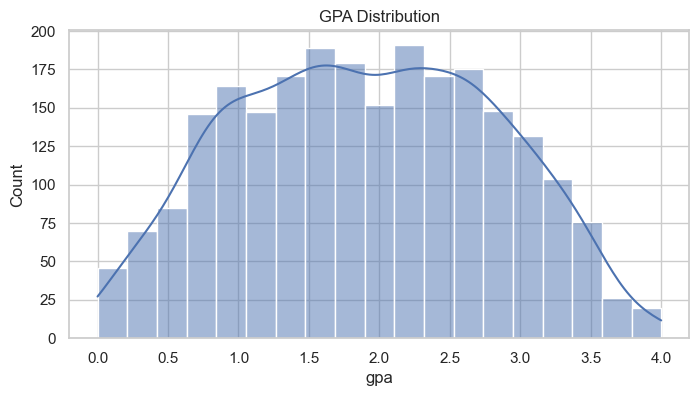

In [94]:
plt.figure(figsize=(8,4))
sns.histplot(df['gpa'], kde=True)
plt.title("GPA Distribution")
plt.savefig('GPA_distribution.png',bbox_inches='tight',facecolor='white')
plt.show()


## Age Distribution  
This reveals how age varies among students.


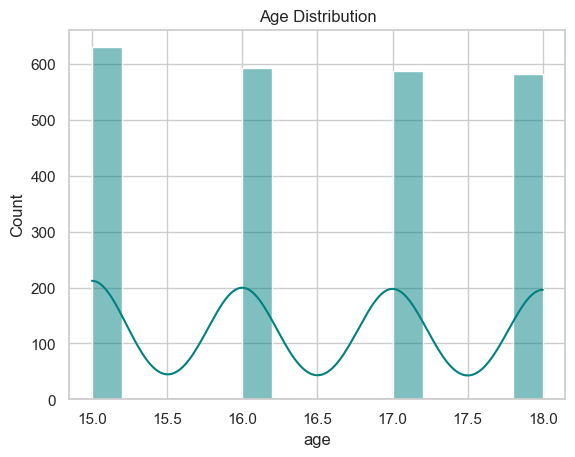

In [93]:
sns.histplot(df['age'], kde=True, bins=15, color="teal")
plt.title("Age Distribution")
plt.savefig('age_distribution.png',bbox_inches='tight',facecolor='white')
plt.show()


##  Study Time vs GPA  
Study hours should ideally show a positive relationship with GPA.


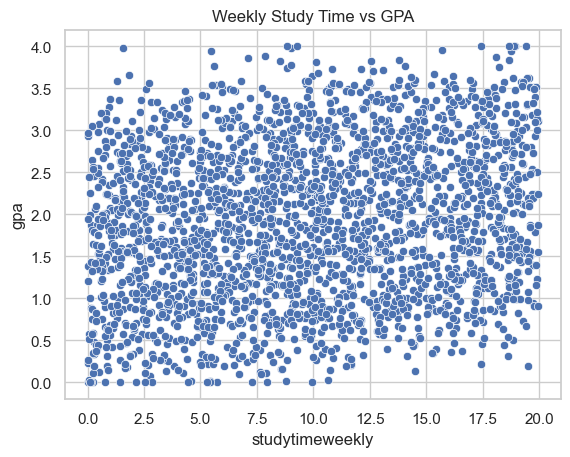

In [92]:
sns.scatterplot(data=df, x='studytimeweekly', y='gpa')
plt.title("Weekly Study Time vs GPA")
plt.savefig('weeklystudytime_vs_GPA.png',bbox_inches='tight',facecolor='white')
plt.show()


##  Absences vs GPA  
Absenteeism usually reduces academic performance.


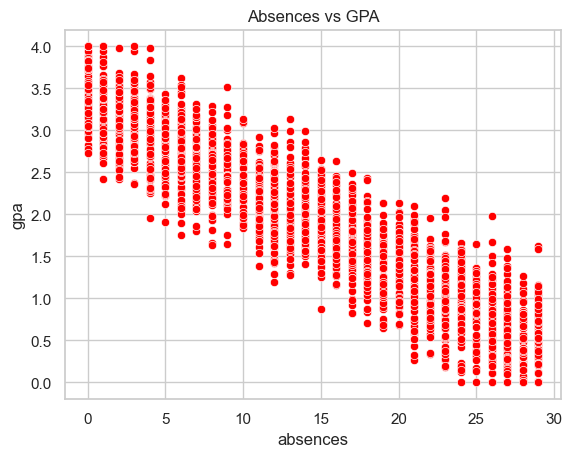

In [91]:
sns.scatterplot(data=df, x='absences', y='gpa', color="red")
plt.title("Absences vs GPA")
plt.savefig('absence_vs_GPA.png',bbox_inches='tight',facecolor='white')
plt.show()


# categorical features
## Gender vs GPA  
We analyze if GPA varies significantly by gender.


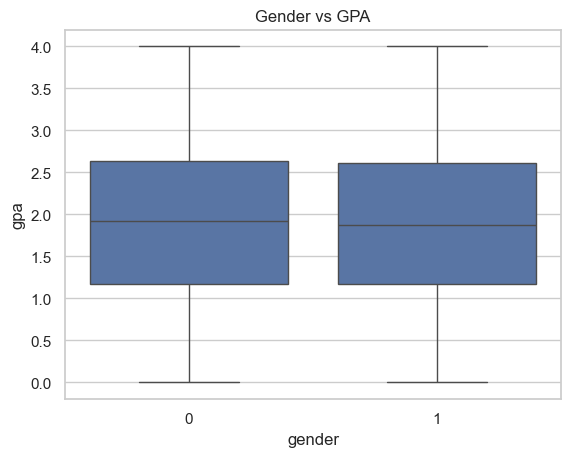

In [90]:
sns.boxplot(data=df, x='gender', y='gpa')
plt.title("Gender vs GPA")
plt.savefig('gender_vs_gpa.png',bbox_inches='tight',facecolor='white')
plt.show()


## Parental Education vs GPA  
Higher parental education levels often correlate with better academic outcomes.


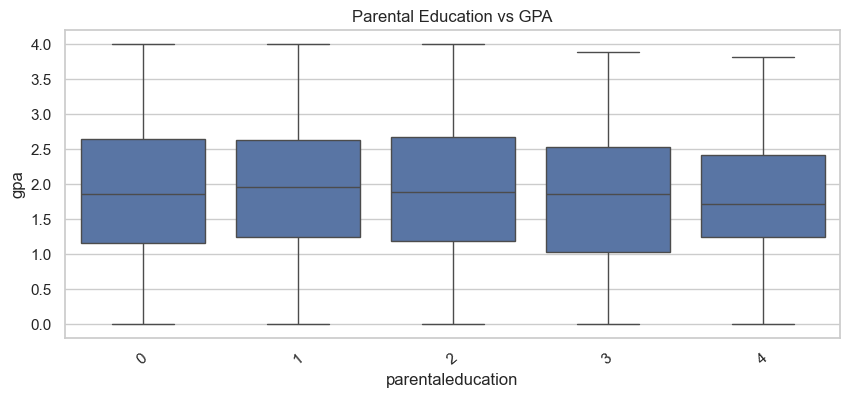

In [89]:
plt.figure(figsize=(10,4))
sns.boxplot(data=df, x='parentaleducation', y='gpa')
plt.xticks(rotation=40)
plt.title("Parental Education vs GPA")
plt.savefig('Parental_Education_vs_GPA.png',bbox_inches='tight',facecolor='white')
plt.show()




##  Parental Support, Tutoring & Activities  
Understanding how external support and participation affect GPA.


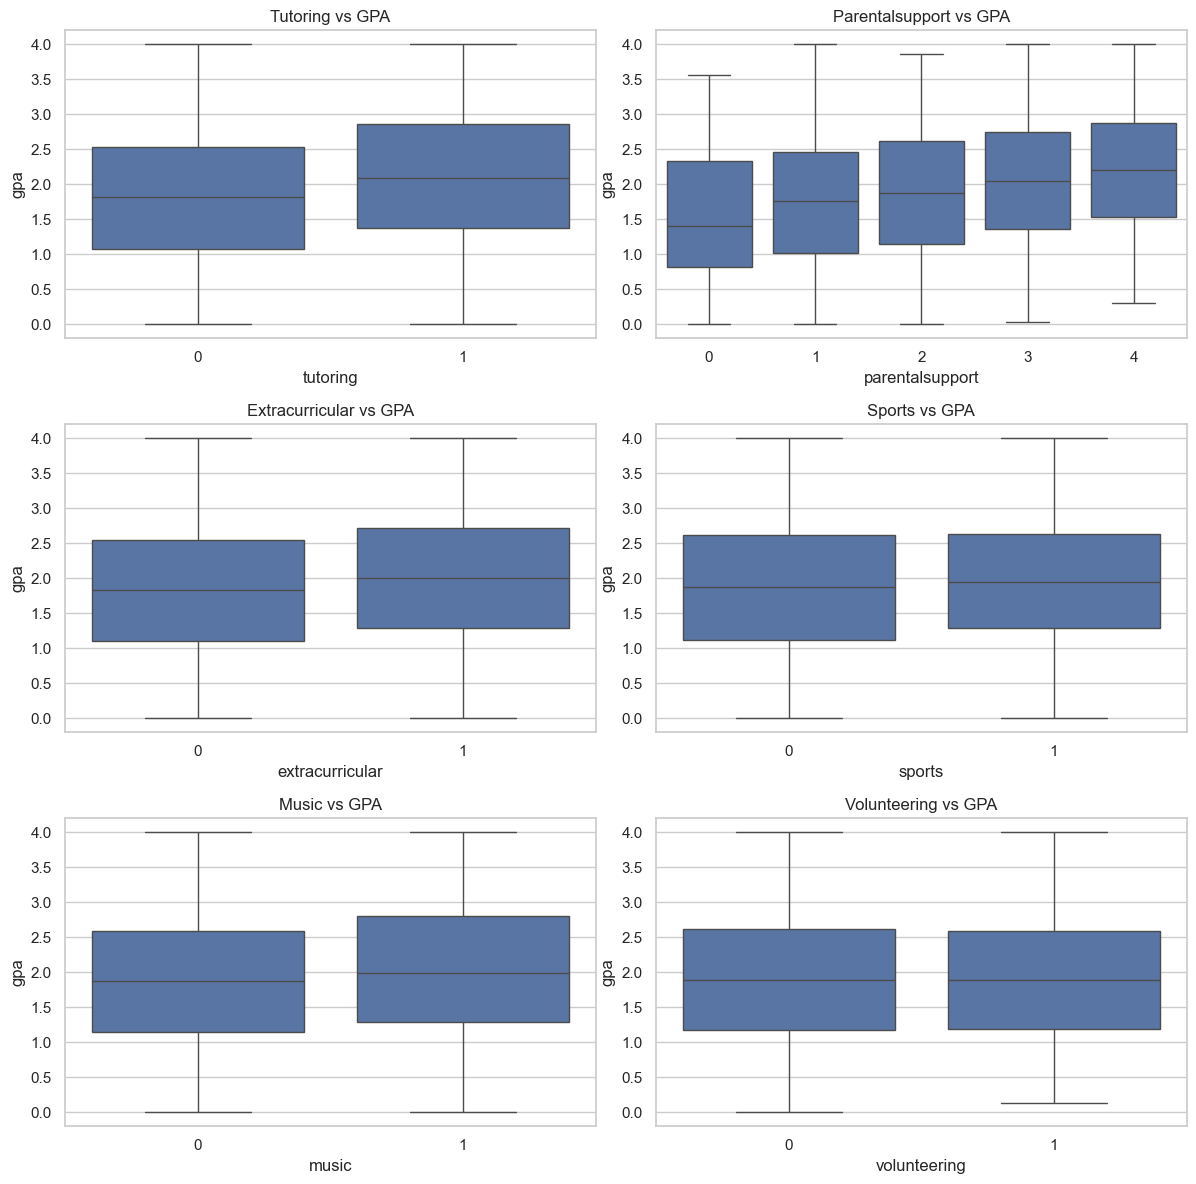

In [97]:
features = ["tutoring", "parentalsupport", "extracurricular", "sports", "music", "volunteering"]

plt.figure(figsize=(12,12))
for i, col in enumerate(features, 1):
    plt.subplot(3,2,i)
    sns.boxplot(x=df[col], y=df['gpa'])
    plt.title(f"{col.capitalize()} vs GPA")

plt.tight_layout()
plt.savefig('parental_support_tutoring_activities.png',bbox_inches='tight',facecolor='white')
plt.show()


##  Correlation Heatmap  
Helps identify how strongly features relate to GPA.


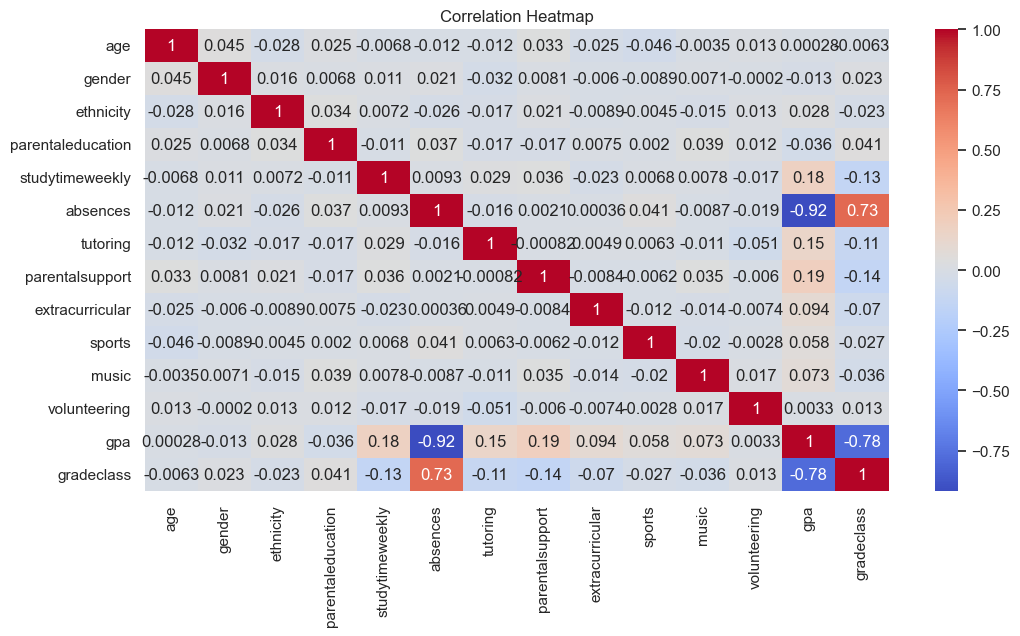

In [95]:
plt.figure(figsize=(12,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.savefig('correlaton_heatmap.png',bbox_inches='tight',facecolor='white')
plt.show()


##  Encoding Categorical Variables  
Machine learning models require numeric input, so we convert categories into numbers using Label Encoding.


In [71]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = [
    'gender', 'ethnicity', 'parentaleducation', 'tutoring',
    'parentalsupport', 'extracurricular', 'sports',
    'music', 'volunteering'
]

df_encoded = df.copy()
le = LabelEncoder()

for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])


In [75]:
x = df_encoded.drop(['gpa','gradeclass'], axis=1)
y = df_encoded['gpa']


In [76]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)


In [77]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

print("Linear Regression:")
print("R2 Score:", r2_score(y_test, lr_pred))
print("MAE:", mean_absolute_error(y_test, lr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))


Linear Regression:
R2 Score: 0.9532471681022928
MAE: 0.15529483485748097
RMSE: 0.1966251293567091


In [78]:
rf = RandomForestRegressor(n_estimators=250, random_state=42)
rf.fit(x_train, y_train)
rf_pred = rf.predict(x_test)

print("Random Forest:")
print("R2 Score:", r2_score(y_test, rf_pred))
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))


Random Forest:
R2 Score: 0.9285738215885481
MAE: 0.18795924929139157
RMSE: 0.24303217158239881


In [79]:
gb = GradientBoostingRegressor(random_state=42)

params = {
    'n_estimators':[150, 200, 250],
    'learning_rate':[0.05, 0.1],
    'max_depth':[2, 3]
}

grid = GridSearchCV(gb, params, cv=4, scoring='r2', n_jobs=-1, verbose=1)
grid.fit(x_train, y_train)

best_gb = grid.best_estimator_
gb_pred = best_gb.predict(x_test)

print("Best Gradient Boosting Model")
print("Best Params:", grid.best_params_)
print("R2 Score:", r2_score(y_test, gb_pred))
print("MAE:", mean_absolute_error(y_test, gb_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, gb_pred)))


Fitting 4 folds for each of 12 candidates, totalling 48 fits
Best Gradient Boosting Model
Best Params: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 200}
R2 Score: 0.9479609572756353
MAE: 0.1618814849110565
RMSE: 0.2074434420070966


In [80]:
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def evaluate_model(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    return {
        "Model": name,
        "R2 Score": round(r2, 4),
        "MAE": round(mae, 4),
        "MSE": round(mse, 4),
        "RMSE": round(rmse, 4)
    }

results = []

results.append(evaluate_model("Linear Regression", y_test, lr_pred))
results.append(evaluate_model("Random Forest", y_test, rf_pred))
results.append(evaluate_model("Gradient Boosting", y_test, gb_pred))

results_df = pd.DataFrame(results)
display(results_df)


,Model,R2 Score,MAE,MSE,RMSE
0,Linear Regression,0.9532,0.1553,0.0387,0.1966
1,Random Forest,0.9286,0.1880,0.0591,0.2430
2,Gradient Boosting,0.9480,0.1619,0.0430,0.2074


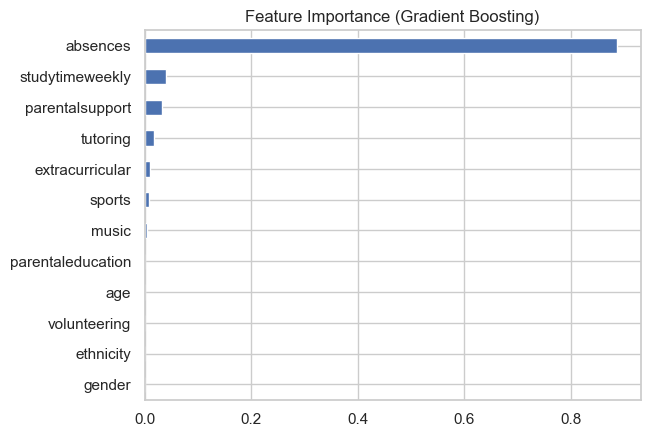

In [98]:
importance = pd.Series(best_gb.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance (Gradient Boosting)")
plt.savefig('feature_importance.png',bbox_inches='tight',facecolor='white')
plt.show()



In [86]:
model1,model2,model3=lr,rf,gb

In [87]:
import pickle

with open("model1.pkl", "wb") as f:
    pickle.dump(model1, f)

with open("model2.pkl", "wb") as f:
    pickle.dump(model2, f)

with open("model3.pkl", "wb") as f:
    pickle.dump(model3, f)
